In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

C:\Users\yan1k\PycharmProjects\heart_disease_kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
DATA_DIR = Path('datasets')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
TARGET = 'Heart Disease'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f'Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Test:  {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')
train_df.head()


Train: 630,000 rows x 15 columns
Test:  270,000 rows x 14 columns


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6000,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8000,2,3,3,Presence


In [14]:
train_feature_columns = [column for column in train_df.columns if column != TARGET]
test_feature_columns = list(test_df.columns)

print('Train data:')
train_df.info()
print('\nTest data:')
test_df.info()


Train data:
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hea

In [36]:
feature_columns = [c for c in train_df.columns if c not in [TARGET, 'id']]
numeric_columns = train_df[feature_columns].select_dtypes(include='number').columns

# replace infinities
for df in (train_df, test_df):
    df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)

# drop duplicate rows
train_df = train_df.drop_duplicates(subset=feature_columns)
test_df = test_df.drop_duplicates(subset=feature_columns)

# check ids
assert train_df['id'].is_unique
assert test_df['id'].is_unique

print(f"Missing values (train): {train_df.isna().sum().sum():,}")
print(f"Missing values (test):  {test_df.isna().sum().sum():,}")

Missing values (train): 0
Missing values (test):  0


In [18]:
target_counts = train_df[TARGET].value_counts().sort_index()
target_shares = target_counts / len(train_df) * 100

for label in target_counts.index:
    print(f'{label}: {target_counts[label]:,} rows ({target_shares[label]:.2f}%)')

Absence: 347,546 rows (55.17%)
Presence: 282,454 rows (44.83%)


Continuous features: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
Categorical features: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


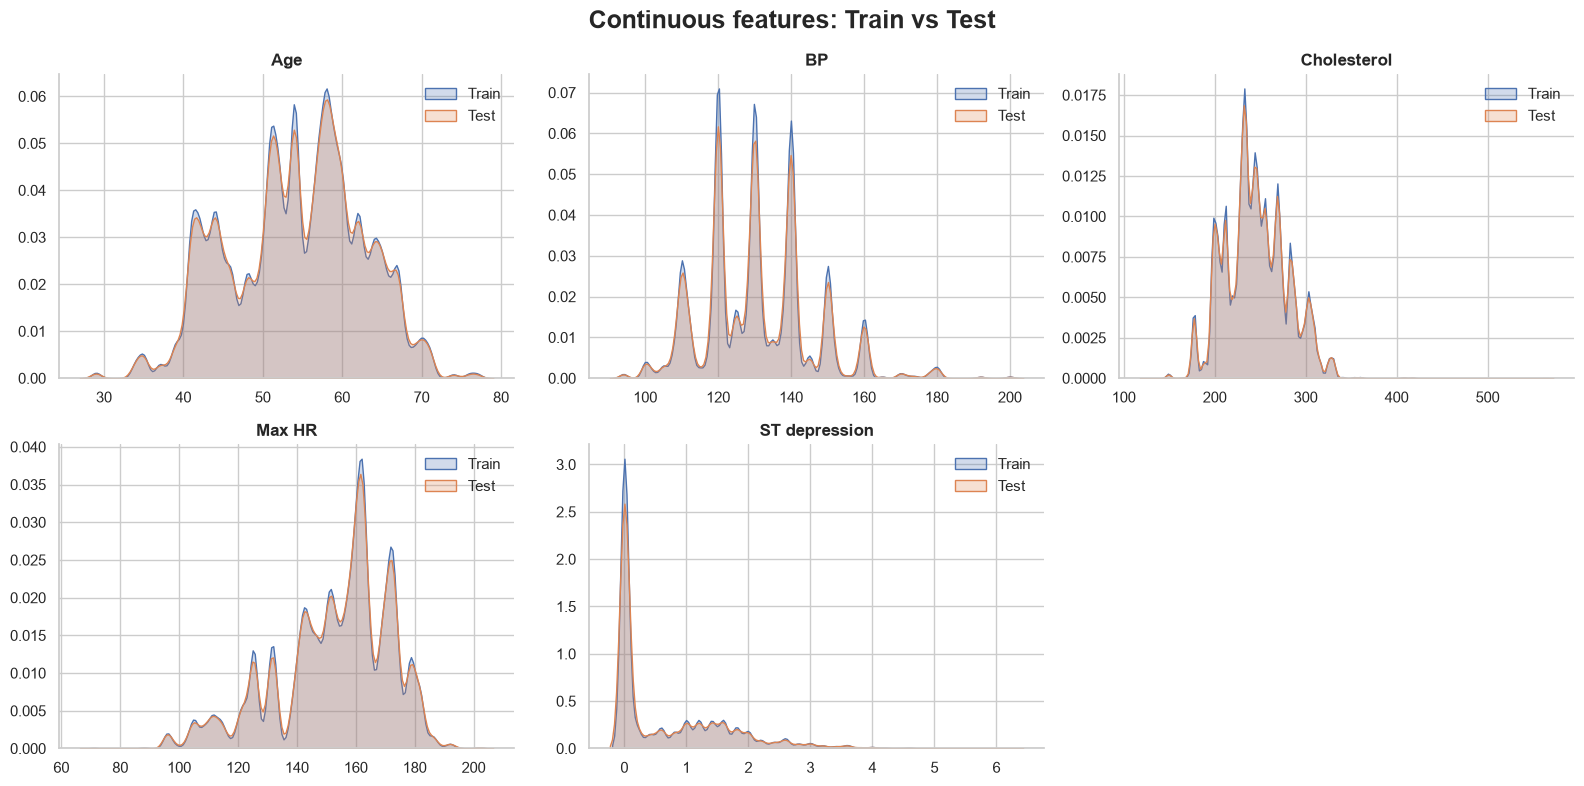

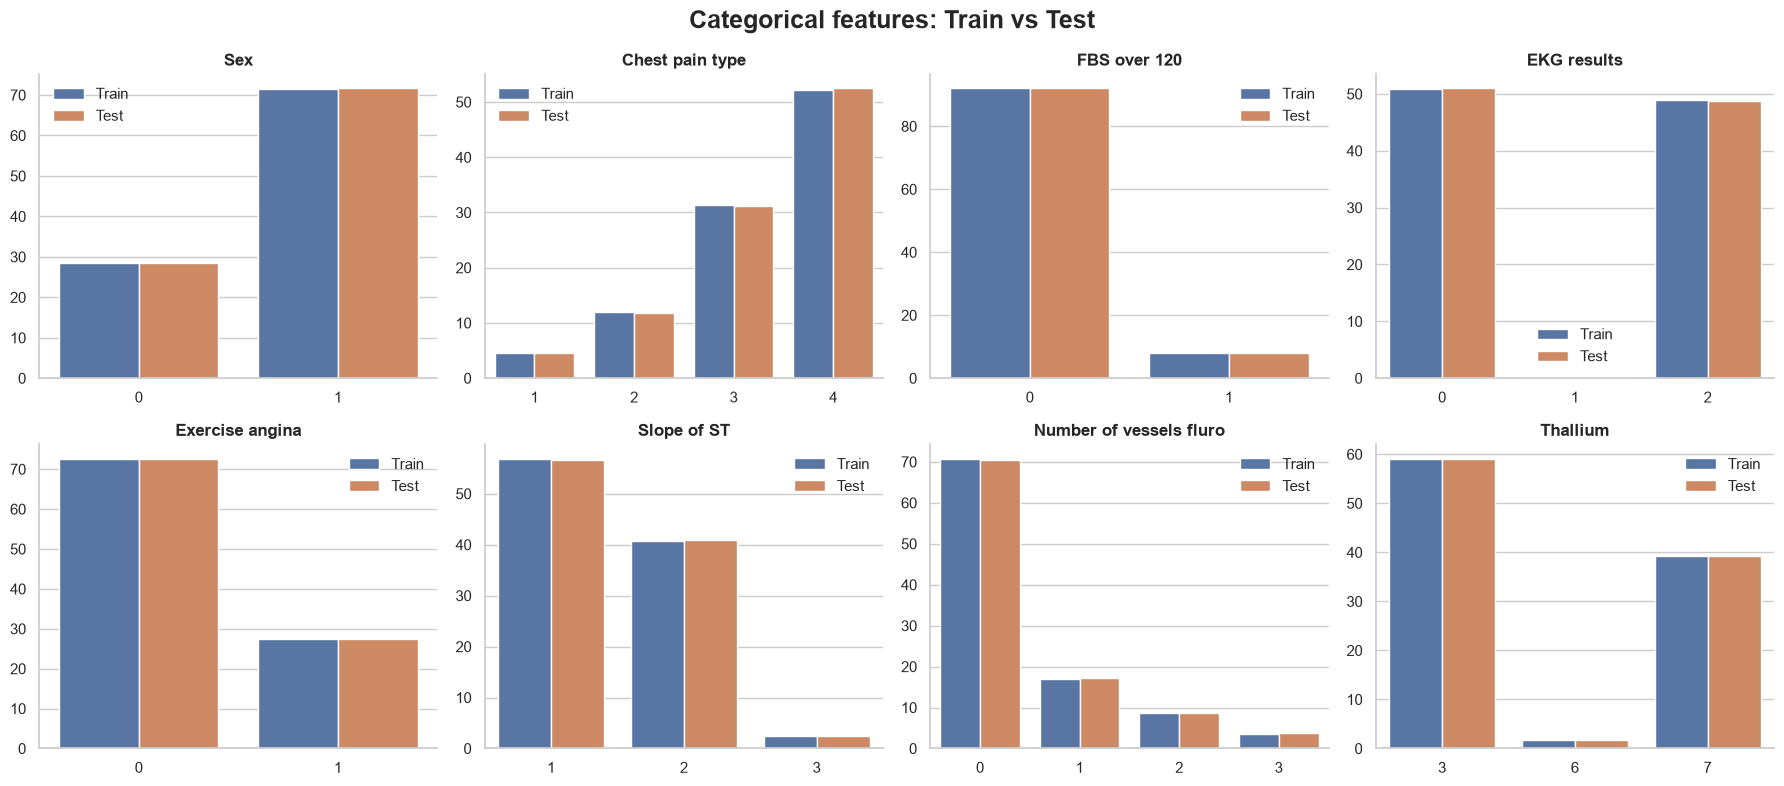

In [30]:
continuous_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = [column for column in feature_columns if column not in continuous_features]

print('Continuous features:', continuous_features)
print('Categorical features:', categorical_features)

def create_grid(nrows, ncols, figsize, title):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.ravel()

    fig.suptitle(title, fontsize=18, weight="bold")

    return fig, axes


def style_axis(ax, title):
    ax.set_title(title, weight="bold")
    ax.set(xlabel="", ylabel="")
    ax.legend(frameon=False)
    ax.tick_params(axis="x", rotation=0)


def finish_grid(fig, axes, features):
    for ax in axes[len(features):]:
        ax.remove()

    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


# Continuous features
fig, axes = create_grid(
    nrows=2,
    ncols=3,
    figsize=(16, 8),
    title="Continuous features: Train vs Test",
)

for ax, col in zip(axes, continuous_features):
    sns.kdeplot(
        data=train_df,
        x=col,
        ax=ax,
        label="Train",
        fill=True,
        alpha=0.25,
    )
    sns.kdeplot(
        data=test_df,
        x=col,
        ax=ax,
        label="Test",
        fill=True,
        alpha=0.25,
    )

    style_axis(ax, col)

finish_grid(fig, axes, continuous_features)


# Categorical features
fig, axes = create_grid(
    nrows=2,
    ncols=4,
    figsize=(18, 8),
    title="Categorical features: Train vs Test",
)

for ax, col in zip(axes, categorical_features):
    plot_df = (
        pd.concat(
            {
                "Train": train_df[col].value_counts(normalize=True),
                "Test": test_df[col].value_counts(normalize=True),
            },
            axis=1,
        )
        .fillna(0)
        .mul(100)
        .rename_axis(col)
        .reset_index()
        .melt(
            id_vars=col,
            var_name="Dataset",
            value_name="Share (%)",
        )
    )

    sns.barplot(
        data=plot_df,
        x=col,
        y="Share (%)",
        hue="Dataset",
        ax=ax,
    )

    style_axis(ax, col)

finish_grid(fig, axes, categorical_features)

In [ ]:
X = pd.read_csv('datasets/train.csv')
cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST',
                'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin',
                'ST_bin']

# Split continuous features into bins
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

X['St_depression_1'] = (X['ST depression'] * 10 % 10).astype(int)

X.replace({'Heart Disease': {'Presence': 1, 'Absence': 0}}, inplace=True)
y = X['Heart Disease'].astype(int)
X.drop(['Heart Disease', 'id'], axis=1, inplace=True)


def objective(trial: optuna.Trial) -> float:
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),

        'iterations': 1000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'task_type': 'GPU',
        'devices': '0',
        'verbose': False
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        test_pool = Pool(X_test, y_test, cat_features=cat_features)

        model = CatBoostClassifier(**params)

        model.fit(train_pool,
                  eval_set=test_pool,
                  early_stopping_rounds=100)

        preds = model.predict_proba(test_pool)[:, 1]
        score = roc_auc_score(y_test, preds)
        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500)

print('Number of finished trials: {}'.format(len(study.trials)))

print('Best trial:')
trial = study.best_trial

print('Value: {}'.format(trial.value))

print('Params: ')
for key, value in trial.params.items():
    print('{}: {}'.format(key, value))

# Best result: 0.955525302701582 with parameters {'iterations': 1209, 'depth': 5, 'learning_rate': 0.08375766130052575, 'l2_leaf_reg': 3.9695263497534183}

In [21]:
X = pd.read_csv('test.csv')

#Bin
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

id = X['id']
X.drop('id', axis=1, inplace=True)
preds = model.predict_proba(X)[:, 1]

sample_submission = pd.DataFrame(data={'id': id, 'Heart Disease': preds})
sample_submission.to_csv('sample_submission.csv', index=False)